# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Import Data and know general info about it

In [5]:
%%time
df = pd.read_csv('CICIDS2018_10Percent.csv')

CPU times: total: 19.5 s
Wall time: 19.9 s


In [7]:
df.head(3)

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,11255034,4,4,486,972,486,0,121.50,...,32,304,0,304,304,6250836.0,0.0,6250836,6250836,DoS attacks-GoldenEye
1,80,6,11875138,4,4,542,972,542,0,135.50,...,32,770,0,770,770,6869523.0,0.0,6869523,6869523,DoS attacks-GoldenEye
2,80,6,5023943,4,4,427,972,427,0,106.75,...,32,0,0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1198955 entries, 0 to 1198954
Data columns (total 79 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1198955 non-null  int64  
 1   Protocol           1198955 non-null  int64  
 2   Flow Duration      1198955 non-null  int64  
 3   Tot Fwd Pkts       1198955 non-null  int64  
 4   Tot Bwd Pkts       1198955 non-null  int64  
 5   TotLen Fwd Pkts    1198955 non-null  int64  
 6   TotLen Bwd Pkts    1198955 non-null  int64  
 7   Fwd Pkt Len Max    1198955 non-null  int64  
 8   Fwd Pkt Len Min    1198955 non-null  int64  
 9   Fwd Pkt Len Mean   1198955 non-null  float64
 10  Fwd Pkt Len Std    1198955 non-null  float64
 11  Bwd Pkt Len Max    1198955 non-null  int64  
 12  Bwd Pkt Len Min    1198955 non-null  int64  
 13  Bwd Pkt Len Mean   1198955 non-null  float64
 14  Bwd Pkt Len Std    1198955 non-null  float64
 15  Flow Byts/s        1194440 non-n

In [13]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 '

# Visualizations 

In [35]:
# Set visual style
sns.set_theme(style="darkgrid", palette="muted")

## 1. Univariate Analysis (Understanding the Raw Metrics)
* These plots look at one column at a time to understand the baseline behavior of the network.

### 1A. Donut Chart: Benign vs. Malicious Traffic
- This chart displays the macro-level ratio of normal network traffic compared to the total volume of all cyberattacks.
- It instantly establishes the baseline class imbalance of our dataset, dictating our approach to model training and evaluation.

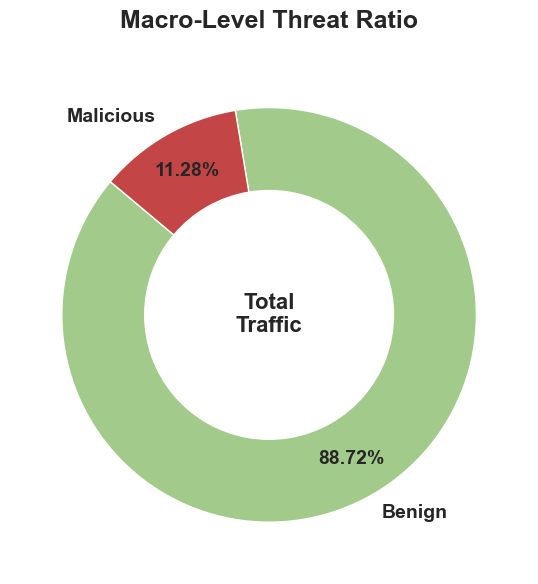

In [18]:
# Group labels into a binary category
macro_labels = df['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Malicious')
macro_counts = macro_labels.value_counts()

# Set up the visual elements
plt.figure(figsize=(6, 6))
# Assign Green for Benign, Red for Malicious for clear cybersecurity context
color_map = {'Benign': '#A2CB8B', 'Malicious': '#C44545'} 
pie_colors = [color_map[label] for label in macro_counts.index]

# Plot the Donut Chart
plt.pie(macro_counts, 
        labels=macro_counts.index, 
        autopct='%1.2f%%', 
        pctdistance=0.80,
        startangle=140, 
        colors=pie_colors, 
        wedgeprops=dict(width=0.4, edgecolor='white'), # The 'width' argument creates the donut hole
        textprops={'fontsize': 14, 'fontweight': 'bold'})

# Add a central text label for presentation polish
plt.text(0, 0, 'Total\nTraffic', ha='center', va='center', fontsize=16, fontweight='bold')

plt.title('Macro-Level Threat Ratio', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('Benign_Malicious_ratio.png')
plt.show()

- We see that almost 90% of the traffic is normal (Benign), and only 11.28% is a Malicious traffic

### 1B. Bar Chart: Label Distribution (Log Scale)
- This chart visualizes the exact row counts for every specific attack category in the dataset.
- Using a logarithmic scale allows us to see the extreme internal imbalance between massive volumetric attacks and extremely rare attacks, highlighting the need for data balancing techniques.

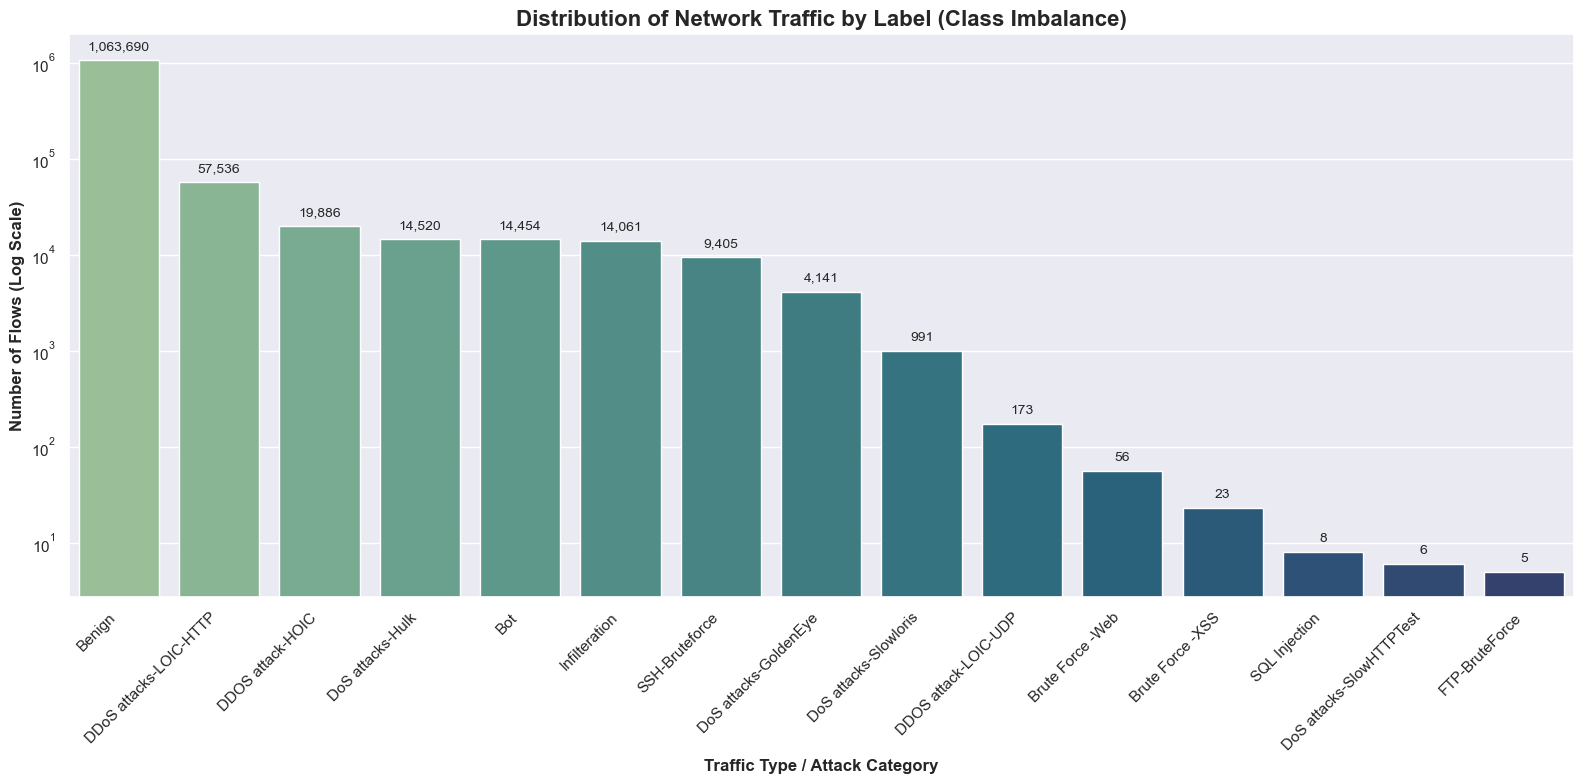

In [53]:
plt.figure(figsize=(16, 8))

ax = sns.countplot(data=df, x='Label', order=df['Label'].value_counts().index, palette='crest')

plt.title('Distribution of Network Traffic by Label (Class Imbalance)', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Flows (Log Scale)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add exact comma-separated numbers on top of the bars for precision
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                textcoords='offset points')

# APPLY LOG SCALE SO MINOR ATTACK CLASSES ARE VISIBLE NEXT TO BENIGN TRAFFIC
plt.yscale('log') 

plt.tight_layout()
plt.savefig('Label_Distribution.png')
plt.show()

### 1C. Overall TCP Flags Frequency
- This visualization aggregates all the standard TCP flags across the entire dataset.
- It provides a macro-view of the protocol mechanics before we split the data by attack type. For instance, normal traffic is usually dominated by connection establishment and data transfer (SYN, ACK, PSH), whereas sudden spikes in RST (Reset), FIN (Finish), or unusual flags (CWE, ECE) can instantly signal scanning or network stress.

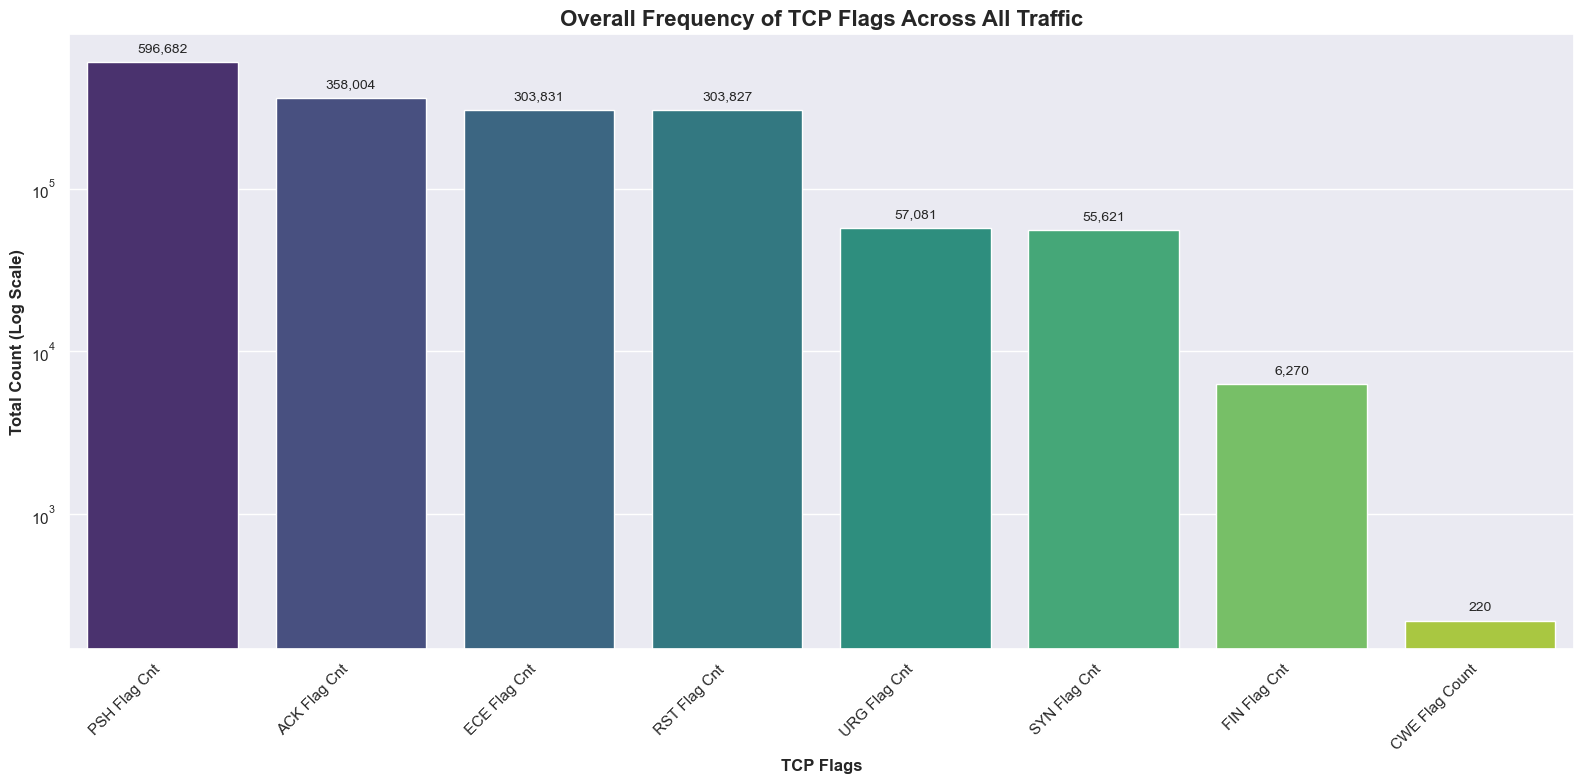

In [55]:
plt.figure(figsize=(16, 8))

# List of the standard TCP flag columns in this dataset
flag_cols = [
    'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 
    'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 
    'CWE Flag Count', 'ECE Flag Cnt'
]

# Defensive check: Only use columns that actually exist in our dataframe 
existing_flags = [col for col in flag_cols if col in df.columns]

# Sum up the occurrences of each flag across all rows and sort them
flag_counts = df[existing_flags].sum().sort_values(ascending=False)

# Create the bar chart
ax = sns.barplot(x=flag_counts.index, y=flag_counts.values, palette='viridis')

plt.title('Overall Frequency of TCP Flags Across All Traffic', fontsize=16, fontweight='bold')
plt.xlabel('TCP Flags', fontsize=12, fontweight='bold')
plt.ylabel('Total Count (Log Scale)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')

# Apply logarithmic scale to handle the massive imbalance between flags
plt.yscale('log')

# Add the exact comma-separated numbers on top of each bar for precision
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.savefig('freq_TCP_Flags.png')
plt.show()

## 2. Bivariate Analysis: Analyse the relation between two columns
* These figures look at two columns at a time to emphasize the reationship between them

### 2A. Protocol Name vs. Attack Type
- This visualization breaks down which transport layer protocols (TCP, UDP, etc.) are utilized by each specific traffic label.
- It reveals protocol-level dependencies (e.g., certain DoS attacks relying purely on TCP or UDP), creating a highly discriminative feature for classification.

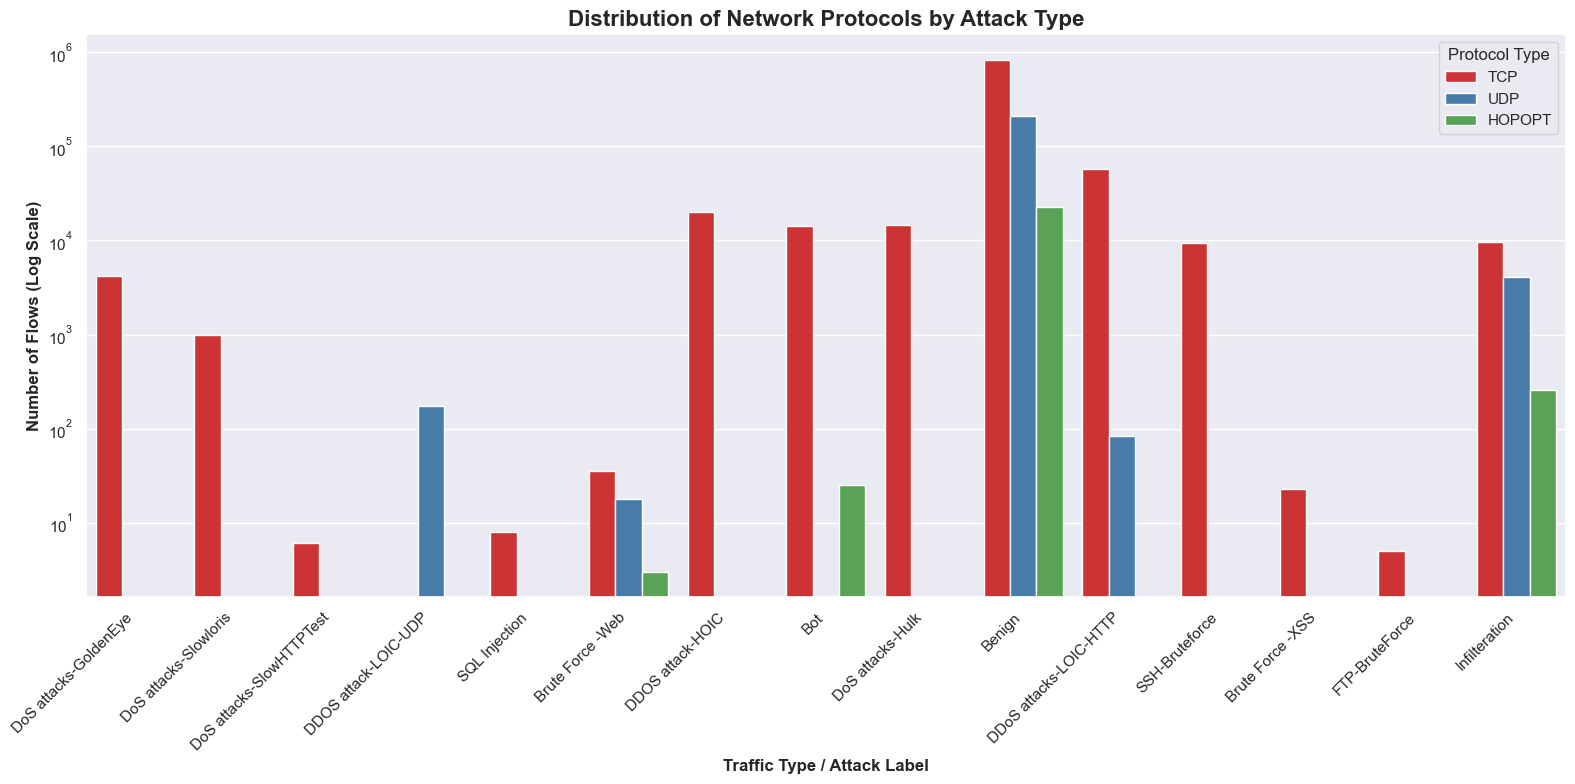

In [25]:
# Define the mapping dictionary
protocol_mapping = {6: 'TCP', 17: 'UDP', 0: 'HOPOPT'}

plt.figure(figsize=(16, 8))

# Map the protocols directly inside the 'hue' argument
ax = sns.countplot(data=df, 
                   x='Label', 
                   hue=df['Protocol'].map(protocol_mapping), 
                   palette='Set1')

plt.title('Distribution of Network Protocols by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Flows (Log Scale)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yscale('log')

# Explicitly set the legend title since we didn't pass a column name to 'hue'
sns.move_legend(ax, "upper right", title='Protocol Type')

plt.tight_layout()
plt.savefig('Protocol-name_Label.png')
plt.show()

### 2B. Destination Port vs Attack Type (Target Profiling)
- This heatmap visualizes the relationship between the top 15 most frequent destination ports and specific attack labels.
- Attackers typically target specific vulnerabilities associated with well-known ports. This plot acts as a behavioral fingerprint, instantly revealing patterns like SSH Brute Force concentrating on Port 22, or web-based attacks (SQLi, XSS, HTTP Floods) heavily targeting Ports 80 and 443.

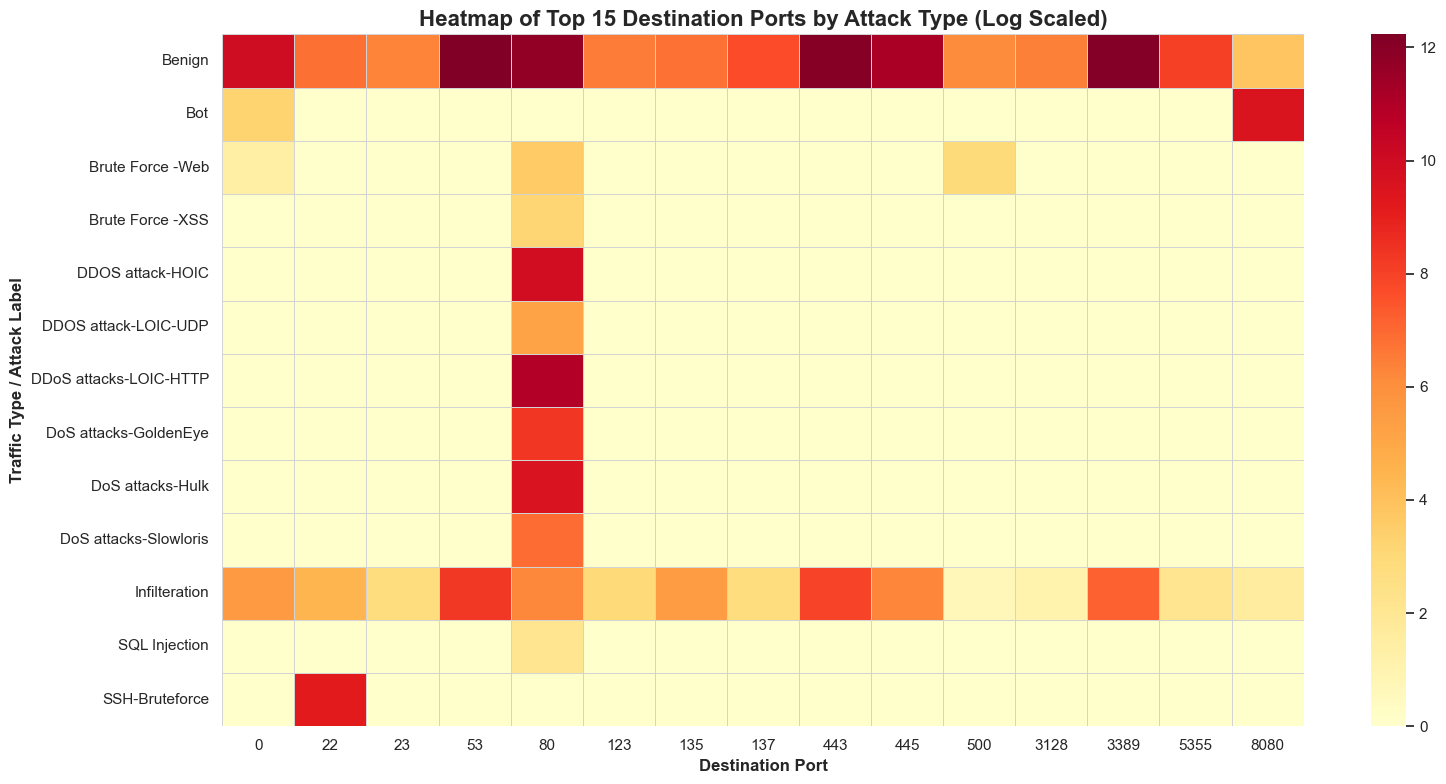

In [27]:
plt.figure(figsize=(16, 8))

# Identify the top 15 most targeted destination ports across the entire dataset
top_ports = df['Dst Port'].value_counts().nlargest(15).index

# Filter the dataframe to only include flows targeting these top ports
df_top_ports = df[df['Dst Port'].isin(top_ports)]

# Create a cross-tabulation matrix of Attack Type vs Destination Port
port_matrix = pd.crosstab(df_top_ports['Label'], df_top_ports['Dst Port'])

# Apply a logarithmic transformation so that attacks with fewer flows 
# are not completely washed out by massive Benign traffic spikes.
port_matrix_log = np.log1p(port_matrix)

# We turn off annotations (annot=False) because the grid colors tell the story perfectly
sns.heatmap(port_matrix_log, 
            cmap='YlOrRd', 
            annot=False, 
            linewidths=0.5, 
            linecolor='lightgray')

plt.title('Heatmap of Top 15 Destination Ports by Attack Type (Log Scaled)', fontsize=16, fontweight='bold')
plt.xlabel('Destination Port', fontsize=12, fontweight='bold')
plt.ylabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')

# Ensure the port numbers on the X-axis are readable
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('Dst-Port_Label.png')
plt.show()

* Because Benign traffic has millions of flows and some attacks only have a few thousand, a normal scale would make the attacks totally invisible. By using a log scale, a "12" translates to roughly 162,000 flows ($e^{12}$), and a "0" means absolutely zero flows. It just compresses huge numbers so you can actually see the patterns.

* This heatmap perfectly maps attack behaviors to their target vulnerabilities. As expected, Benign traffic naturally spreads across common ports like 53 (DNS), 80 (HTTP), and 443 (HTTPS). However, the malicious signatures stand out vividly: SSH-Bruteforce is exclusively locked onto Port 22, Bot traffic heavily targets Port 8080, and you can see a massive, solid red pillar on Port 80 where all the DoS and DDoS attacks concentrate their floods.

### 2C. Fwd URG Flags vs. Label Values
- This plot isolates the activation of the TCP Urgent (URG) flag in the forward direction across different attack types.
- Since the URG flag is largely obsolete in normal modern traffic, tracking its rare usage helps us identify highly specific, mechanical signatures of certain threat vectors.

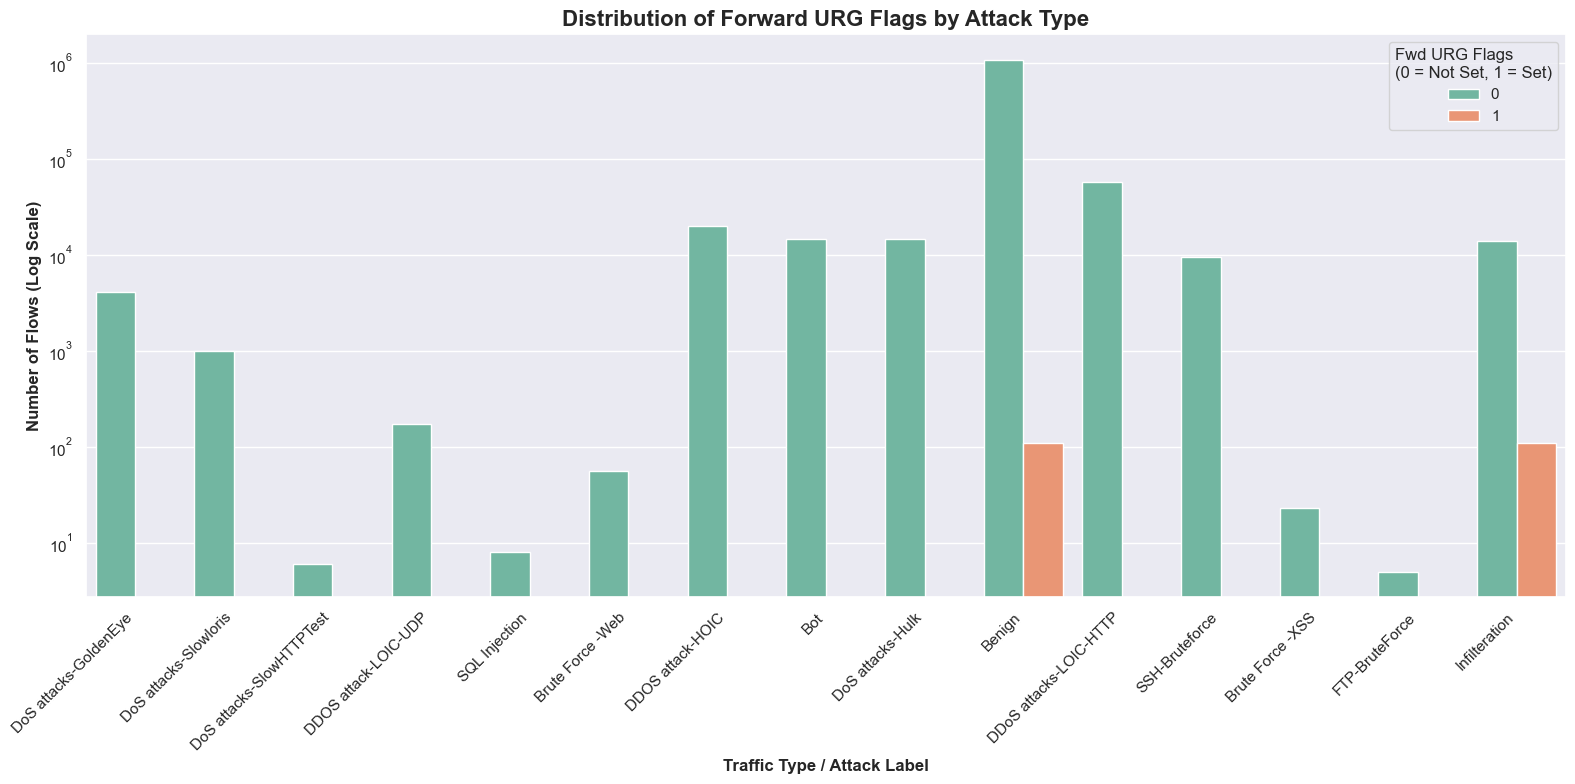

In [57]:
plt.figure(figsize=(16, 8))

# Create a countplot grouping by Label and splitting colors by the URG Flag status
ax = sns.countplot(data=df, 
                   x='Label', 
                   hue='Fwd URG Flags', 
                   palette='Set2')

plt.title('Distribution of Forward URG Flags by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Flows (Log Scale)', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the attack names don't overlap
plt.xticks(rotation=45, ha='right')

# Apply a logarithmic scale because the number of flows with '0' flags 
# will completely dwarf the flows with '1' flags
plt.yscale('log')

# Move the legend so it doesn't cover our data
sns.move_legend(ax, "upper right", title='Fwd URG Flags\n(0 = Not Set, 1 = Set)')

plt.tight_layout()
plt.savefig('FWD-URG-Flags_Label.png')
plt.show()

### 2D. Distribution of ECE Flags by Attack Type (Congestion Profiling)
- This countplot displays how often the ECE (Explicit Congestion Notification Echo) flag is activated (1) versus not set (0) across different traffic labels.
- ECE flags signal heavy network congestion. Tracking this helps identify if volumetric attacks (like DDoS floods) are naturally triggering congestion warnings on the network, or if specific threat vectors are actively manipulating TCP congestion control mechanisms.

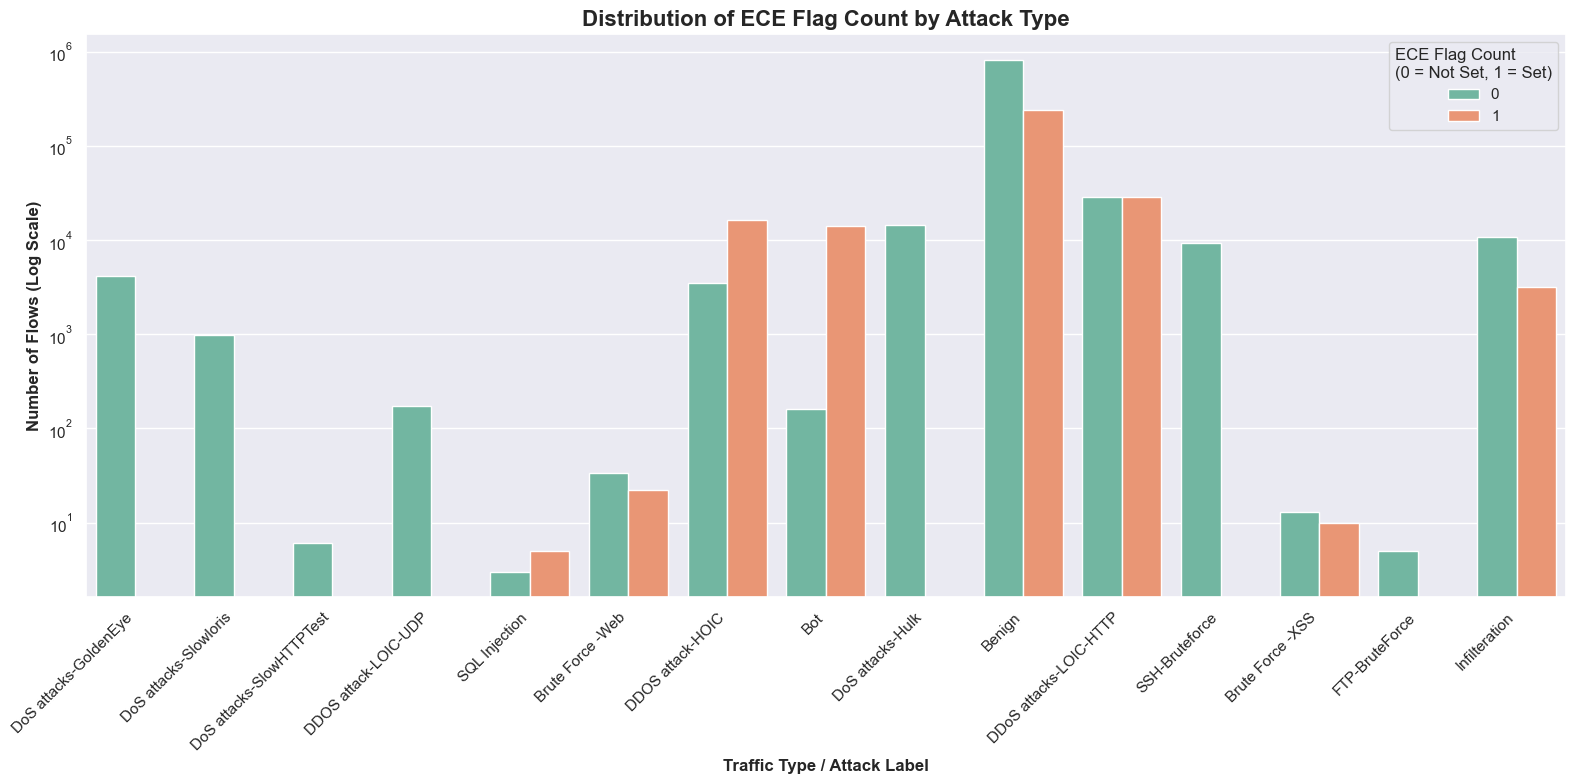

In [48]:
plt.figure(figsize=(16, 8))

# Create a countplot grouping by Label and splitting colors by the ECE Flag status
ax = sns.countplot(data=df, 
                   x='Label', 
                   hue='ECE Flag Cnt', 
                   palette='Set2')

plt.title('Distribution of ECE Flag Count by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Flows (Log Scale)', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the attack names don't overlap
plt.xticks(rotation=45, ha='right')

# Apply a logarithmic scale
plt.yscale('log')

# Move the legend
sns.move_legend(ax, "upper right", title='ECE Flag Count\n(0 = Not Set, 1 = Set)')

plt.tight_layout()
plt.savefig('ECE-Flag-Cnt_Label.png')
plt.show()

### 2E. Initial Forward Window Bytes vs Attack Type
- This boxplot visualizes the `Init Fwd Win Byts` (the size of the initial TCP window sent in the forward direction) across different traffic labels.
- **Why it matters:** The initial window size is a low-level behavioral fingerprint. Legitimate operating systems use standard, dynamically scaled window sizes to optimize data transfer. In contrast, automated attack tools, custom malware, and DoS scripts frequently hardcode this value to unusual numbers, or set it to `0` or `-1` (indicating raw sockets or non-standard TCP handshakes), creating a highly detectable signature.

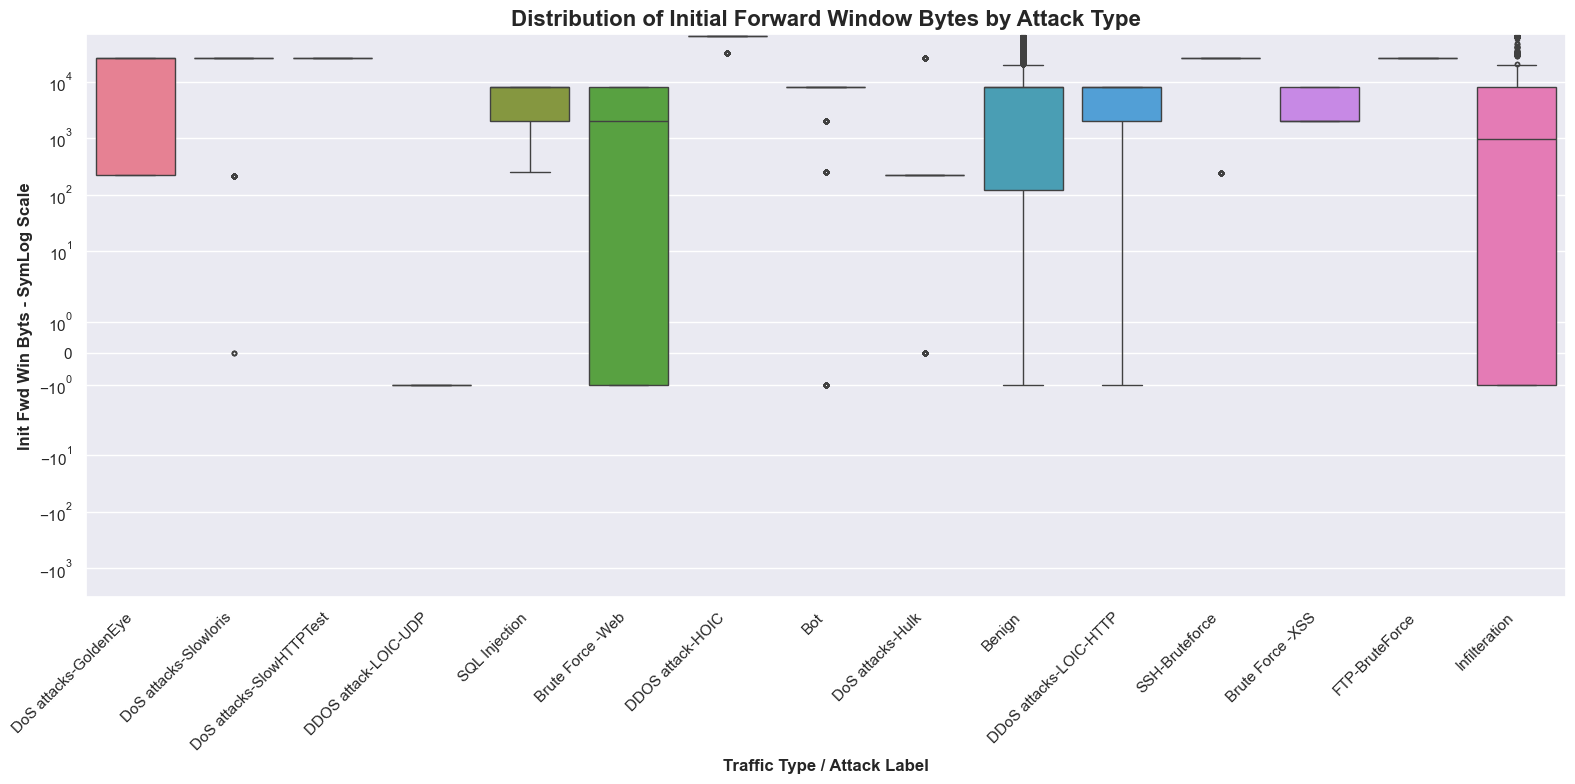

In [59]:
plt.figure(figsize=(16, 8))

# We use 'husl' palette to give it a distinct look from previous plots
sns.boxplot(data=df, 
            x='Label', 
            y='Init Fwd Win Byts', 
            palette='husl', 
            fliersize=3)

plt.title('Distribution of Initial Forward Window Bytes by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Init Fwd Win Byts - SymLog Scale', fontsize=12, fontweight='bold')

# Rotate the labels so the attack names are readable
plt.xticks(rotation=45, ha='right')

# Apply Symmetrical Log scale to safely handle 0 and -1 values common in this feature
plt.yscale('symlog')

plt.tight_layout()
plt.savefig('Init-Fwd-Win-Byts_Label.png')
plt.show()

- **The Dynamic Baseline:** Benign traffic has a tall, wide box spanning many different values. This is because real operating systems (Windows, Mac, Linux) constantly and dynamically adjust their TCP window sizes based on network conditions.
- **The Hardcoded Fingerprint:** Notice how attacks like Slowloris, SlowHTTPTest, HOIC, SSH-Bruteforce, and FTP-BruteForce are just flat lines at the very top (around the 20,000 to 65,000 range). This means the attack script doesn't adjust its window size; it uses a single, hardcoded value for every single packet. This zero-variance behavior is a massive red flag for your ML models.
- **The UDP Identifier:** DDoS attack-LOIC-UDP is entirely crushed at -1. This makes perfect sense: UDP is a connectionless protocol and doesn't use window sizes. The dataset uses -1 to represent this, creating a clean mathematical split between TCP and UDP attacks.

### 2F. Download/Upload Ratio by Attack Type
- This plot analyzes the ratio of incoming data to outgoing data for each specific attack label.
- It exposes the asymmetry of data transfer. It helps clearly differentiate between interactive, balanced traffic (like normal human browsing) and blind, asymmetric attacks (like volumetric floods that blast data outward without waiting for responses).

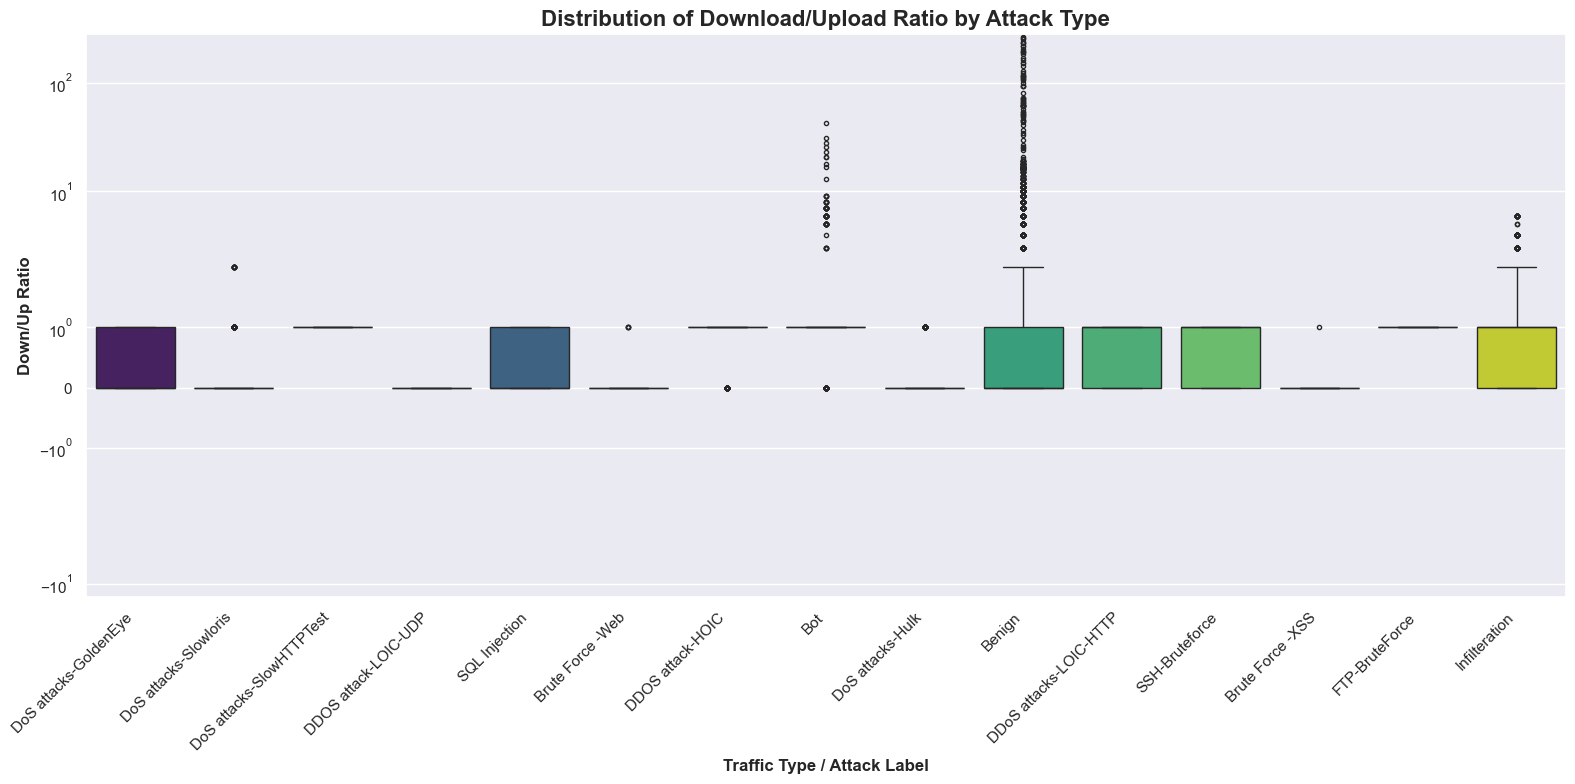

In [61]:
plt.figure(figsize=(16, 8))

# Create the boxplot to see the median ratio and outliers per attack
sns.boxplot(data=df, 
            x='Label', 
            y='Down/Up Ratio', 
            palette='viridis', 
            fliersize=3)

plt.title('Distribution of Download/Upload Ratio by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Down/Up Ratio', fontsize=12, fontweight='bold')

# Rotate the labels so the attack names are easily readable
plt.xticks(rotation=45, ha='right')

# Symmetrical Log scale
plt.yscale('symlog')

plt.tight_layout()
plt.savefig('Down-Up_Label.png')
plt.show()

* The Benign Traffic Baseline: "Benign" traffic has the largest spread of extreme outliers stretching above $10^2$ (a ratio of 100+). This precisely reflects normal human internet use: streaming videos or downloading files involves receiving massive amounts of data while uploading almost nothing.
* The "Zero-Ratio" Signature (Brute Force & Floods): Notice how attacks like SSH-Bruteforce, FTP-BruteForce, DoS attacks-Hulk, and DDoS attack-LOIC-UDP are completely flattened at exactly 0. This proves they are blindly blasting requests or password guesses at the target server and receiving almost nothing in return. Their upload volume vastly outweighs their download volume.
* The "Perfect Symmetry" Fingerprint: Attacks like DDoS attack-HOIC and DoS attacks-SlowHTTPTest are completely flat at exactly $10^0$ (1). This indicates a strict 1:1 ratio. The attack script likely sends a packet and waits for a specific acknowledgment before proceeding, creating an artificial, robotic symmetry that stands out from human traffic.
* The Infiltration Disguise: Infiltration is the only attack class that displays a normal-looking boxplot spread (spanning from 0 to 1) mimicking Benign traffic. This aligns with reality: infiltration usually involves an attacker interactively exploring a compromised network, typing commands, and exfiltrating files, which naturally creates varied upload/download ratios similar to regular users.
* Botnet Beacons: The Bot category is mostly flat near 0 but has a distinct vertical string of outliers. This visually represents classic Botnet "beaconing": the infected machine continuously sends tiny check-in packets outward (Ratio = 0), but occasionally downloads a larger payload of instructions from its Command & Control server (the outliers).

### 2G. Active Mean Time vs. Traffic Types
- This boxplot compares the average time that connections remain active before terminating, categorized by attack type.
- Time is a crucial behavioral metric. This allows us to visually separate quick "hit-and-run" attacks from lingering threats (like Botnets) that hold connections open unnaturally.

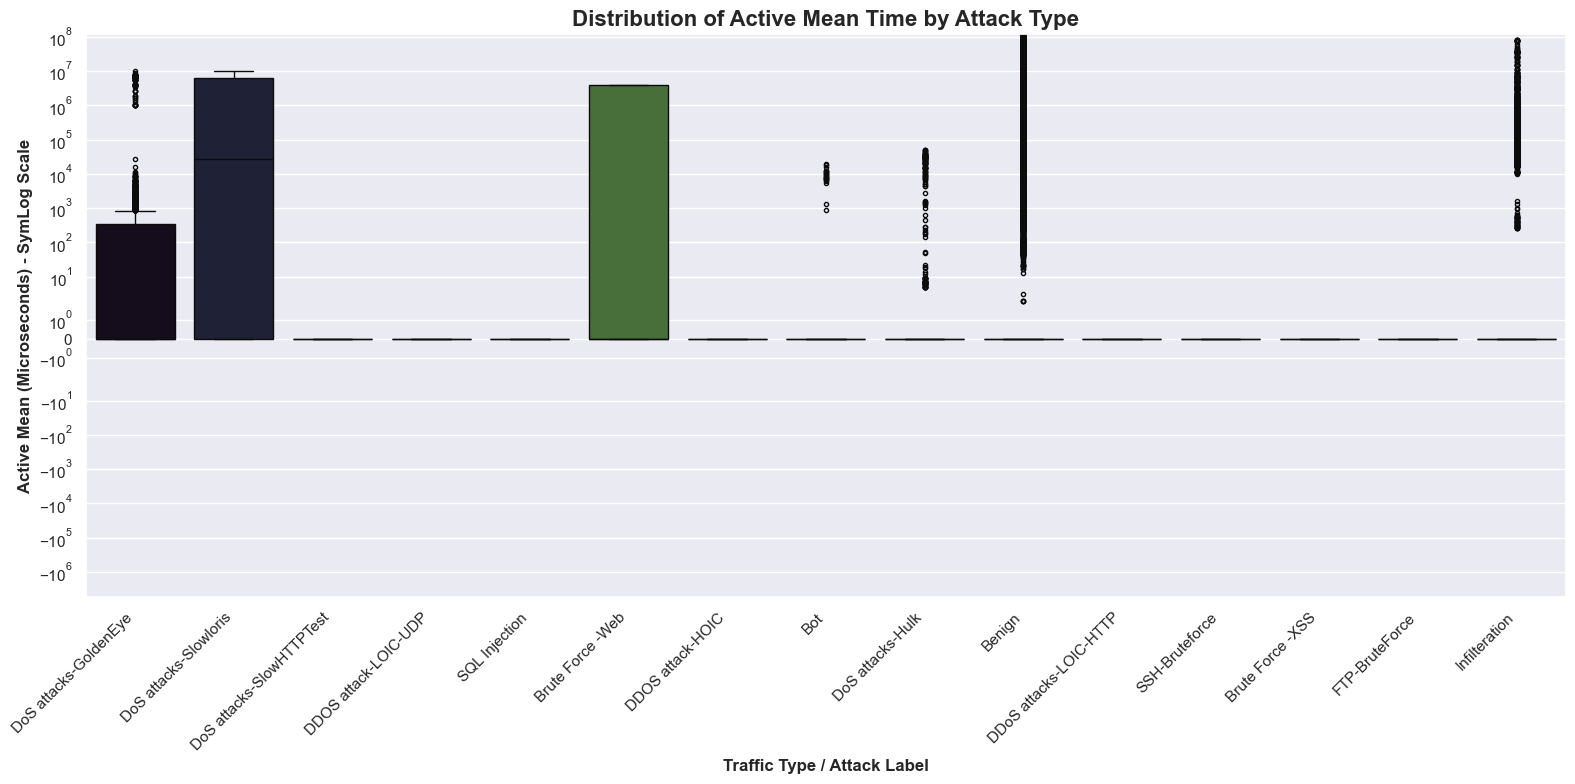

In [63]:
plt.figure(figsize=(16, 8))

# Create the boxplot
# Using a distinct palette like 'cubehelix' to separate it visually from previous charts
sns.boxplot(data=df, 
            x='Label', 
            y='Active Mean', 
            palette='cubehelix', 
            fliersize=3)

plt.title('Distribution of Active Mean Time by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Active Mean (Microseconds) - SymLog Scale', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')

# Apply Symmetrical Log scale
plt.yscale('symlog')

plt.tight_layout()
plt.savefig('Active-Mean-Time_Label.png')
plt.show()

### 2H. Flow Bytes/s vs Attack Type (Bandwidth Profiling)
- This boxplot profiles the raw bandwidth speed (`Flow Byts/s`) generated by different types of traffic.
- **Why it matters:** Attackers have vastly different bandwidth footprints. A Volumetric DDoS attack aims to saturate network pipes, resulting in massive Bytes/s spikes. Conversely, attacks like Slowloris deliberately send data as slowly as possible to tie up server resources, resulting in abnormally low Bytes/s compared to normal Benign traffic.

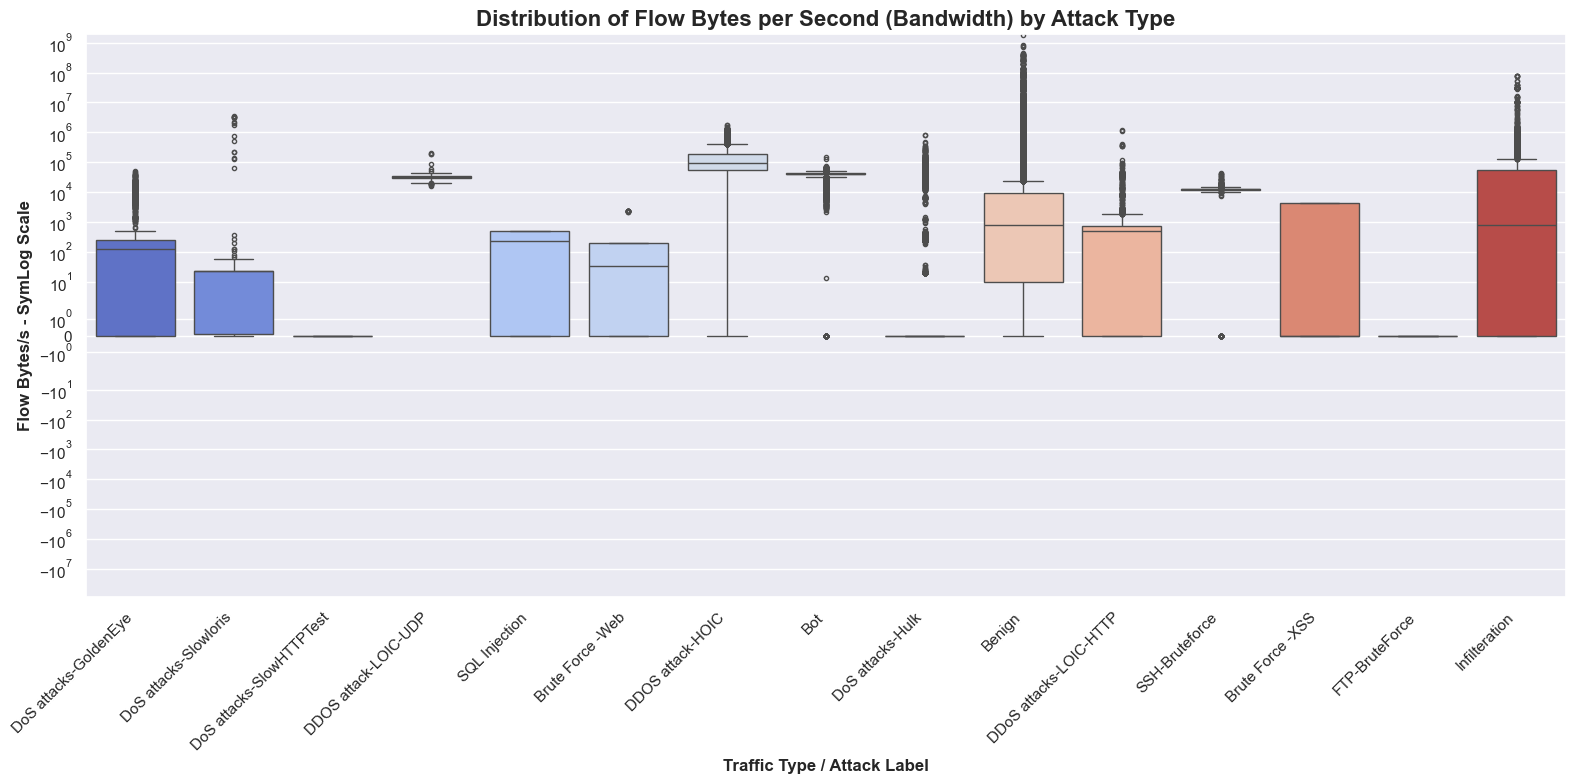

In [65]:
# CRITICAL FIX for CIC-IDS: 'Flow Byts/s' often contains Infinity (caused by division by 0 duration)
# We create a temporary DataFrame that replaces Inf with NaN, then drops them just for this plot
plot_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Flow Byts/s'])

plt.figure(figsize=(16, 8))

# Create the boxplot
# Using the 'coolwarm' palette to contrast high volume (hot) vs low volume (cool)
sns.boxplot(data=plot_df, 
            x='Label', 
            y='Flow Byts/s', 
            palette='coolwarm', 
            fliersize=3)

plt.title('Distribution of Flow Bytes per Second (Bandwidth) by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type / Attack Label', fontsize=12, fontweight='bold')
plt.ylabel('Flow Bytes/s - SymLog Scale', fontsize=12, fontweight='bold')

# Rotate the labels
plt.xticks(rotation=45, ha='right')

# Apply Symmetrical Log scale
plt.yscale('symlog')

plt.tight_layout()
plt.savefig('Flow-Byts_Label.png')
plt.show()

- **High-Volume Signatures:** Attacks like DDOS attack-HOIC and Infiltration show significantly high median bandwidths and wide spreads, reaching up to $10^6$ Bytes/s. This is classic behavior for volumetric attacks or large data exfiltration, designed to overwhelm network capacity.
- **Low-Volume/Stealth Signatures:** Conversely, DoS attacks-Slowloris and DoS attacks-SlowHTTPTest have median bandwidths near 0. This perfectly aligns with their design: they intentionally send data as slowly as possible to keep server connections open and exhaust resources without triggering volume-based alarms.
- **The Benign Baseline:** Notice how the Benign traffic has a massive spread, stretching from near 0 up to almost $10^9$ Bytes/s. This reflects the huge variety of normal internet use, from simple text messaging (low bandwidth) to 4K video streaming (high bandwidth).

## 3. Multivariate Analysis :

### 3A. Complete Correlation Heatmap of Numerical Variables
- This massive matrix displays the correlation coefficients between all numerical features in the dataset.
- It allows us to immediately spot multicollinearity (features that copy each other), dictating which redundant variables must be dropped to optimize our Machine Learning algorithms.

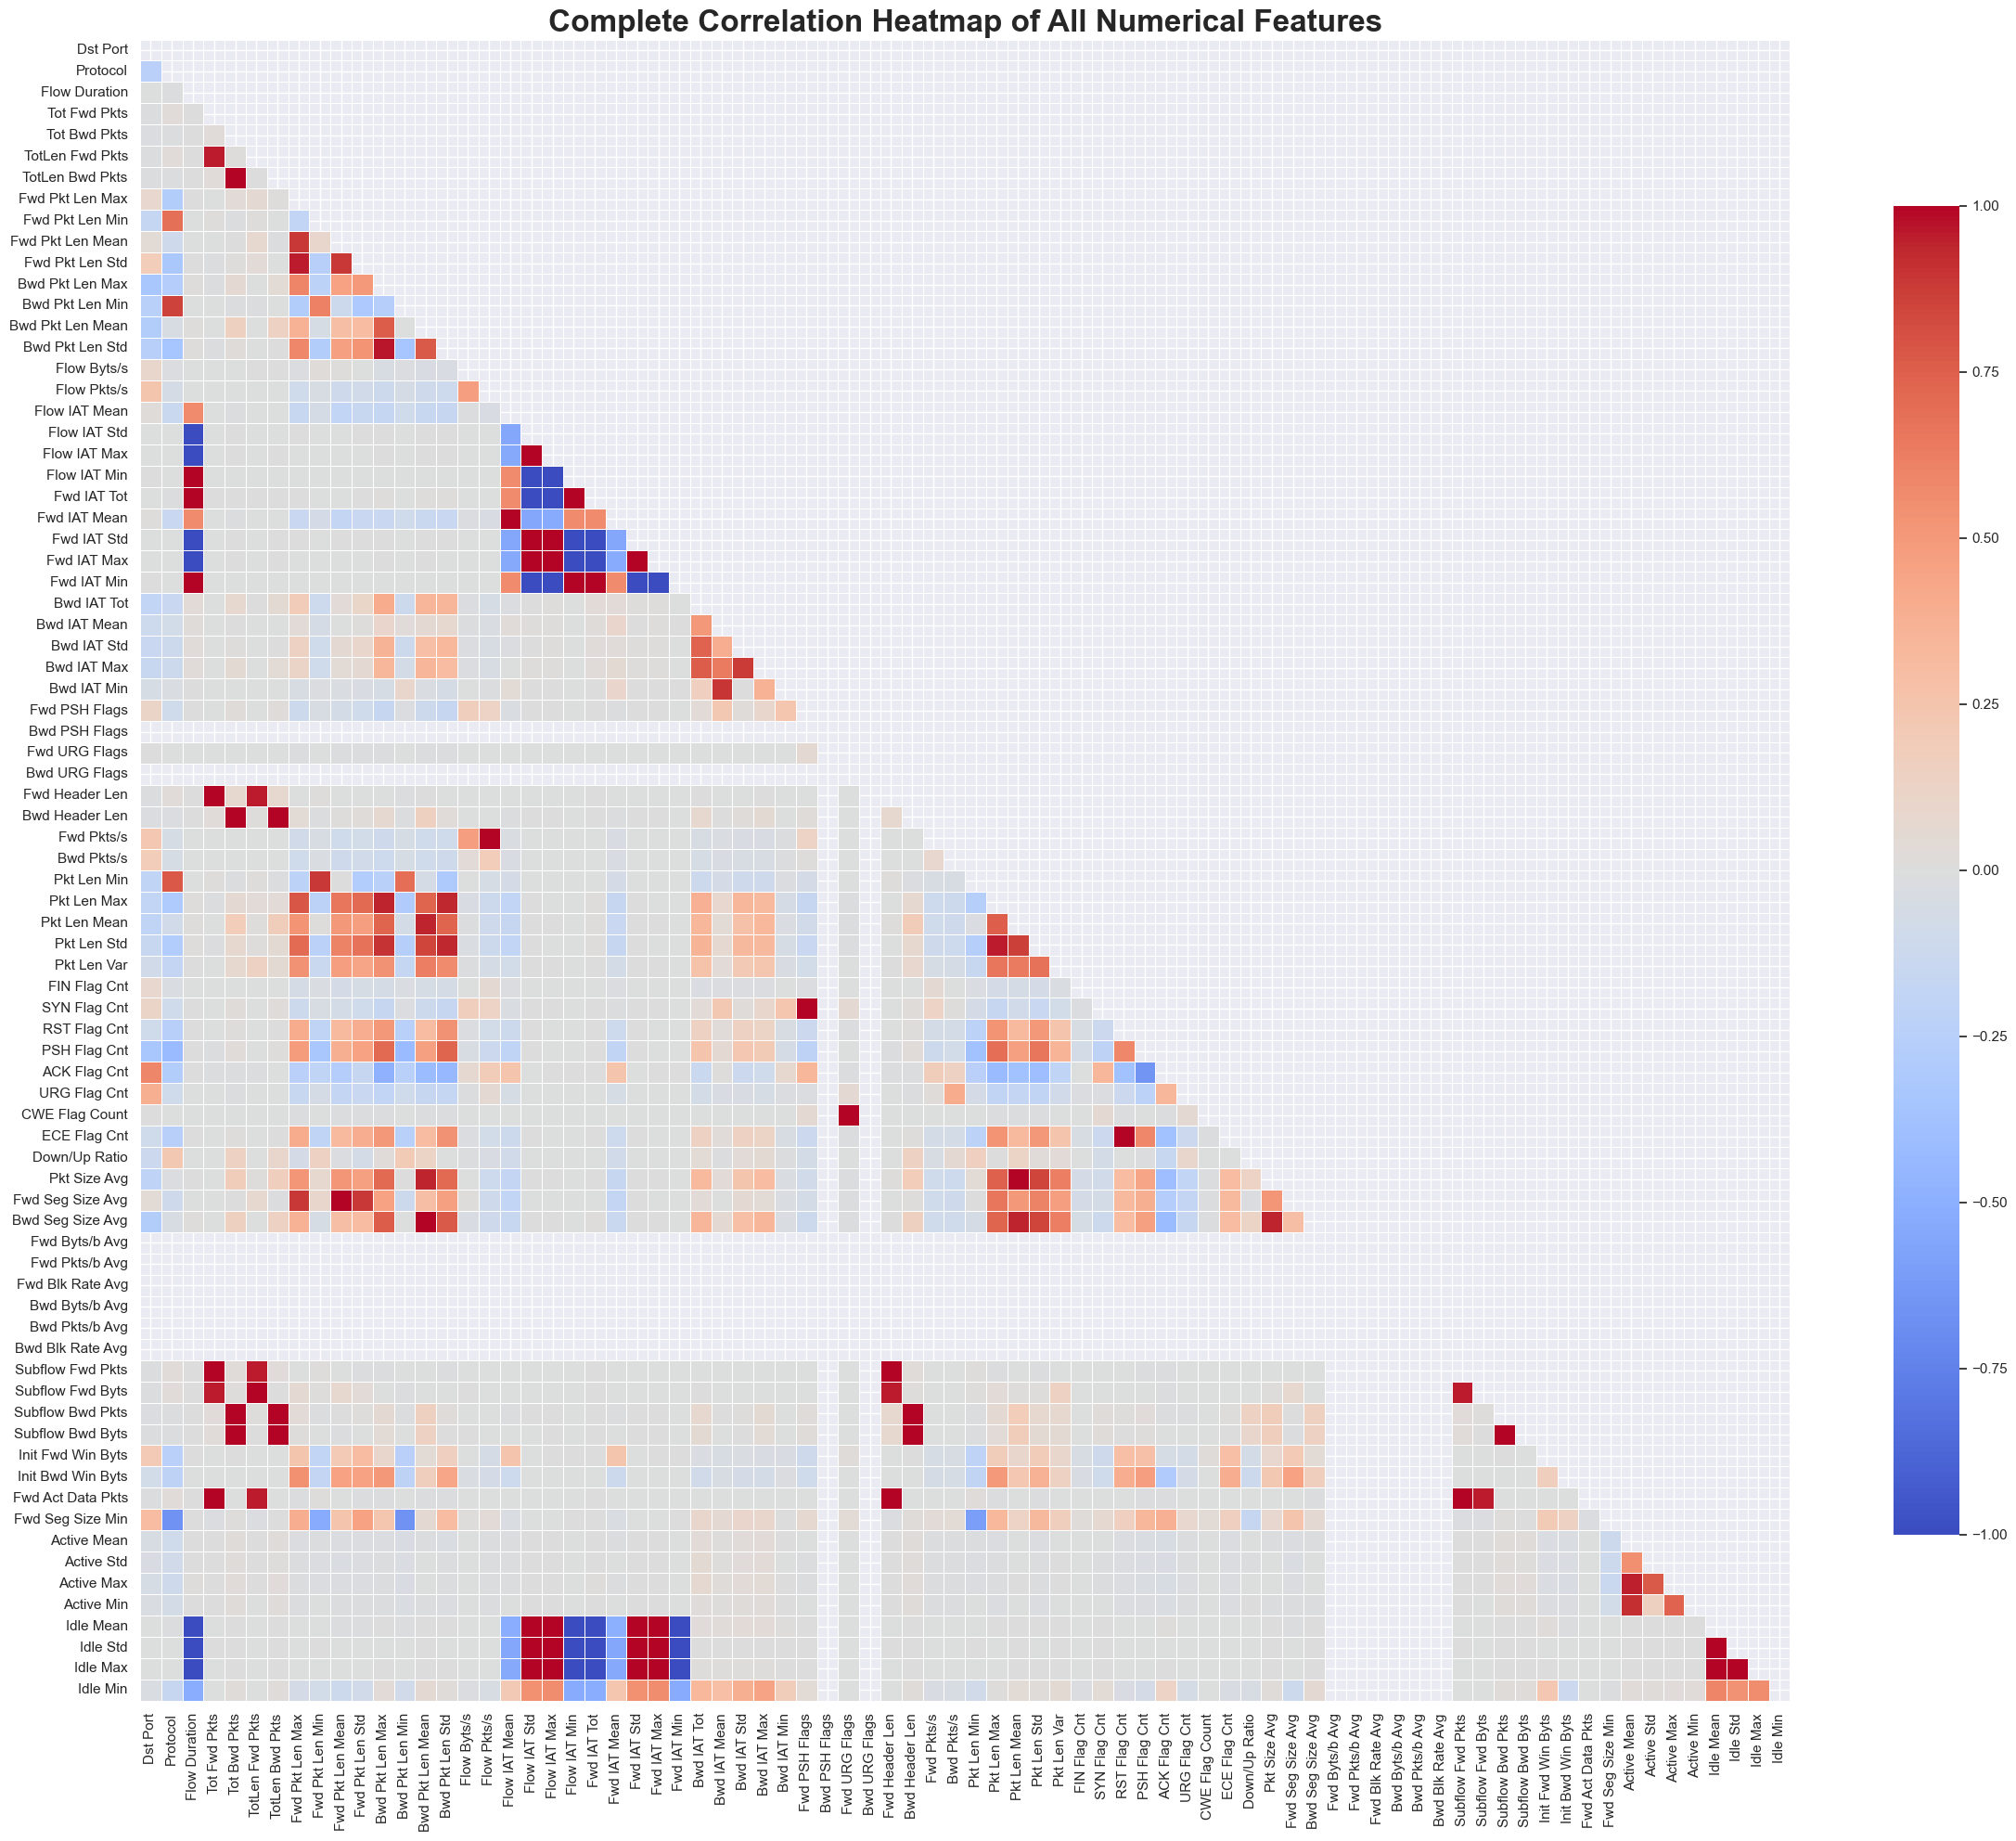

In [47]:
# Automatically isolate ONLY numerical columns to avoid errors
numerical_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numerical_df.corr()

# Create a mask to hide the upper triangle to prevents duplicate visual info.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(24, 20))

# annot=False is mandatory here, otherwise the numbers will be an unreadable black blur
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            annot=False, 
            linewidths=0.5, 
            vmin=-1, vmax=1, 
            cbar_kws={"shrink": .8}) # Shrinks the color bar slightly for aesthetics

plt.title('Complete Correlation Heatmap of All Numerical Features', fontsize=24, fontweight='bold')

plt.tight_layout()
plt.savefig('Heatmap_Numerical-Features.png')
plt.show()

### 3B. Mean Feature Heatmap per Attack Type (Attack Fingerprinting)
- This normalized heatmap displays the average values of 10 highly distinct network features across every attack label.
- **Methodology:** Each column (feature) is Min-Max scaled individually from 0 to 1. A value of `1` (darkest color) means that specific attack type holds the highest average for that feature across the entire dataset.
- **Why it matters:** This acts as a visual "fingerprint" for our classification models. For example, it allows us to instantly see that Botnets max out "Idle Mean", while DDoS attacks max out "Flow Pkts/s", proving that our chosen features successfully and uniquely separate the attack classes.

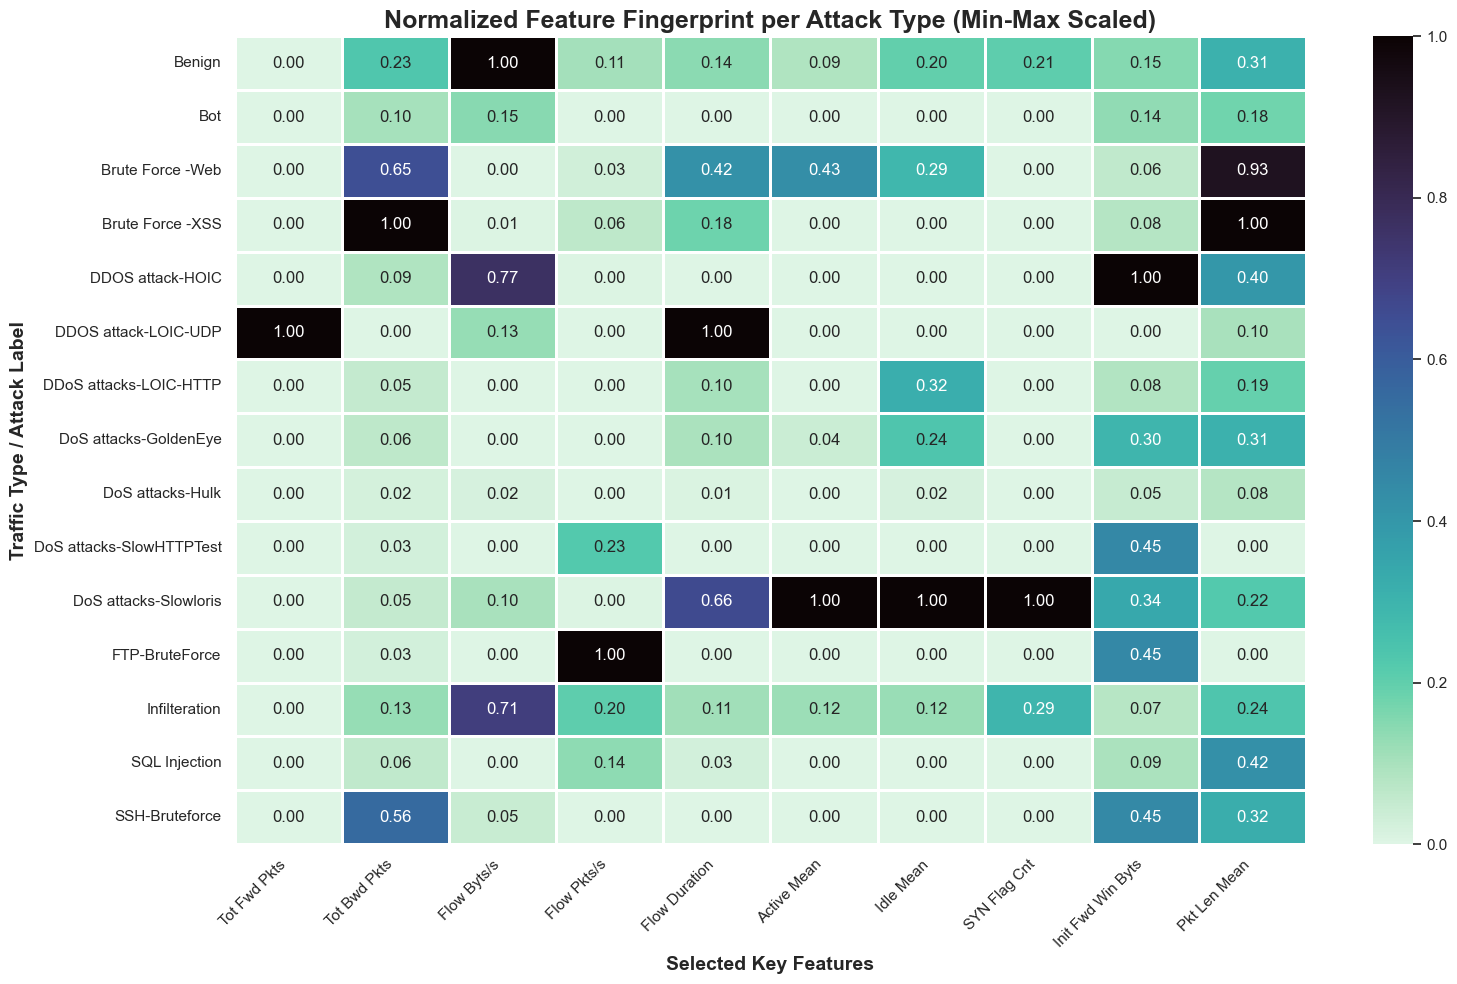

In [48]:
# Define the 10 "Golden Features" that best represent network behavior
key_features = [
    'Tot Fwd Pkts', 'Tot Bwd Pkts', 
    'Flow Byts/s', 'Flow Pkts/s', 
    'Flow Duration', 'Active Mean', 'Idle Mean', 
    'SYN Flag Cnt', 'Init Fwd Win Byts', 
    'Pkt Len Mean'
]

# Defensive check: ensure features exist in our dataframe
features_to_use = [f for f in key_features if f in df.columns]

# Handle Infinity values in Bytes/s or Pkts/s
clean_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=features_to_use)

# Calculate the Mean for each feature, grouped by Attack Label
mean_df = clean_df.groupby('Label')[features_to_use].mean()

# Apply Min-Max Scaling PER COLUMN (0 to 1 scale)
# This is mandatory so massive numbers (Duration) don't hide small numbers (Packet Counts)
normalized_df = (mean_df - mean_df.min()) / (mean_df.max() - mean_df.min())

plt.figure(figsize=(16, 10))

# 'mako' or 'viridis' are excellent
sns.heatmap(normalized_df, 
            cmap='mako_r',  # _r reverses it so dark = high value
            annot=True,
            fmt=".2f",
            linewidths=1, 
            linecolor='white')

plt.title('Normalized Feature Fingerprint per Attack Type (Min-Max Scaled)', fontsize=18, fontweight='bold')
plt.xlabel('Selected Key Features', fontsize=14, fontweight='bold')
plt.ylabel('Traffic Type / Attack Label', fontsize=14, fontweight='bold')

# Rotate X labels
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('Heatmap_10Features_Label.png')
plt.show()

#### Observations: Normalized Feature Fingerprint per Attack Type

This heatmap reveals distinct behavioral signatures per attack type across 10 key network features:

- **DoS attacks-Slowloris** stands out with the highest `Active Mean` (1.00), `Idle Mean` (1.00),
  and `SYN Flag Cnt` (1.00), confirming its strategy of holding connections open as long as possible.

- **DDOS attack-LOIC-UDP** dominates `Tot Fwd Pkts` (1.00) and `Flow Duration` (1.00),
  consistent with a high-volume, sustained UDP flood that sends massive amounts of packets.

- **Brute Force -XSS** and **FTP-BruteForce** show the highest `Flow Pkts/s` (1.00 each),
  reflecting the rapid, repetitive request pattern typical of automated brute force tools.

- **DDOS attack-HOIC** peaks at `Init Fwd Win Byts` (1.00), suggesting a hardcoded or
  abnormal TCP window size — a known artifact of automated attack scripts.

- **Benign** traffic has the highest `Flow Byts/s` (1.00), which is expected as normal
  traffic includes large file transfers and streaming, unlike most attacks that send small,
  repetitive packets.

- **Bot**, **DoS attacks-Hulk**, and **SQL Injection** show uniformly low values across
  all features, indicating stealthy, low-volume behavior designed to evade detection.

> Overall, this fingerprint heatmap confirms that no single feature separates all attack
> types — but the **combination** of timing, volume, rate, and TCP behavior features
> creates a unique signature per attack class, which directly motivates a multi-feature
> machine learning approach.

### 3C. Radar (Spider) Charts per Attack Type (Visual Fingerprinting)
- This grid of radar charts takes the normalized feature data from our heatmap and projects it into a geometric space.
- **Why it matters for presentation:** Human eyes are highly trained to recognize shape discrepancies. By displaying these 10 key behavioral metrics on a circular axis, each attack forms a distinct geometric polygon. This instantly communicates to the jury how completely different a volumetric flood looks compared to a stealthy infiltration or a brute-force script, proving the robustness of our selected feature set.

Successfully saved: Radar_10Features_Label_pt1.png


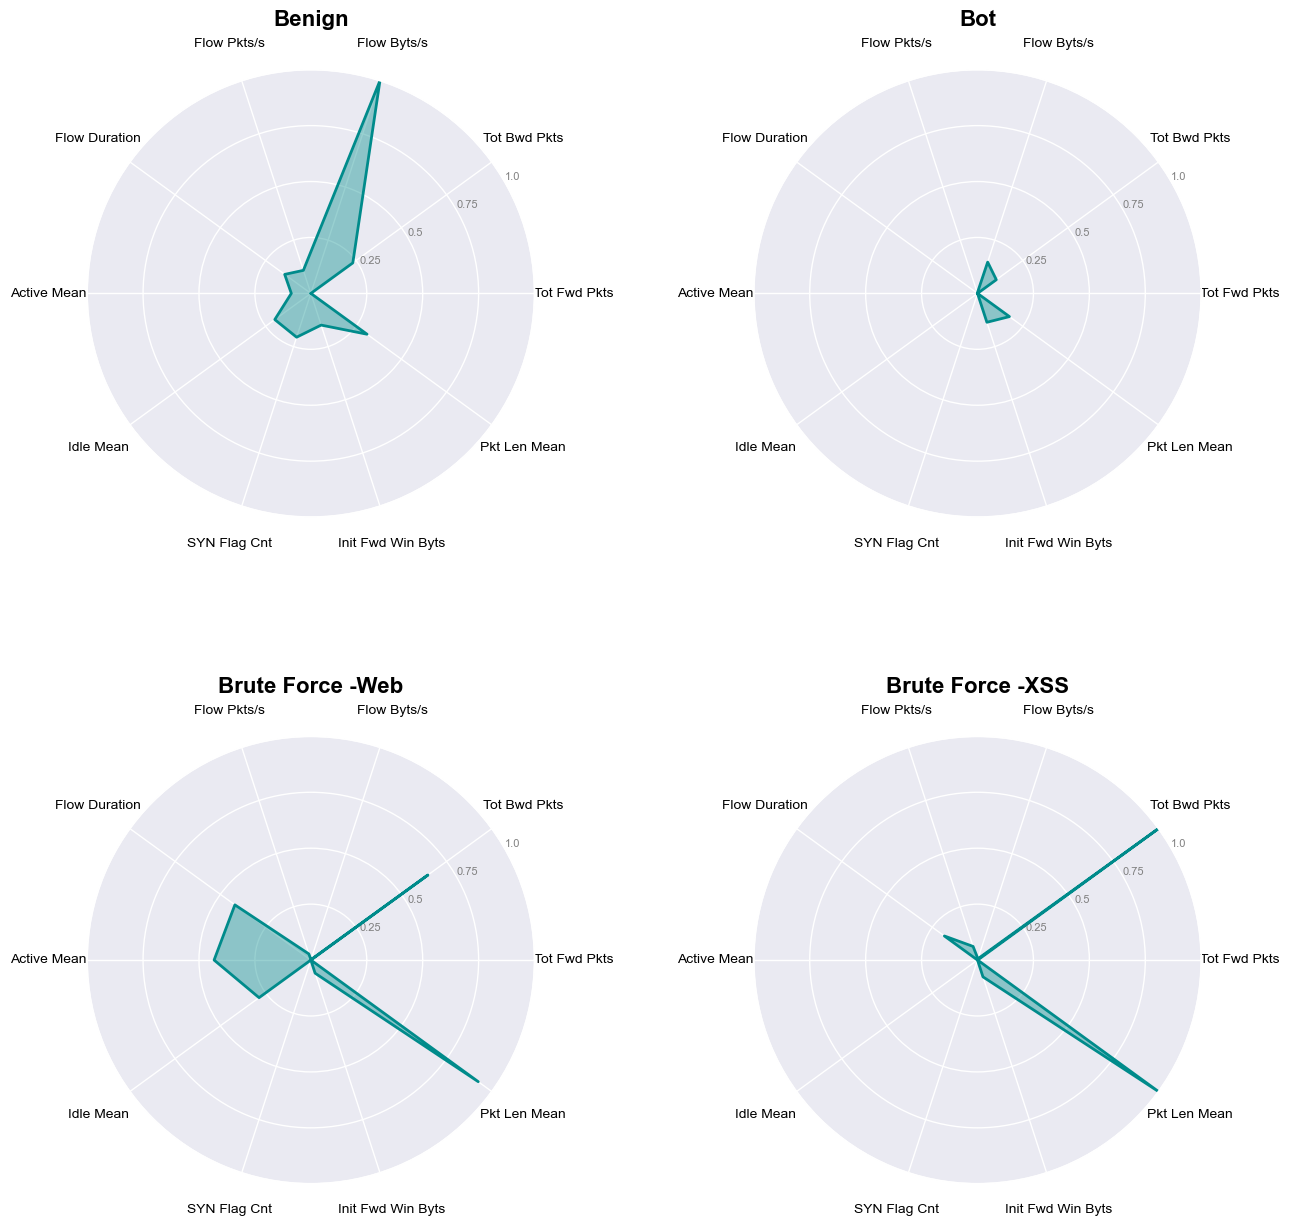

Successfully saved: Radar_10Features_Label_pt2.png


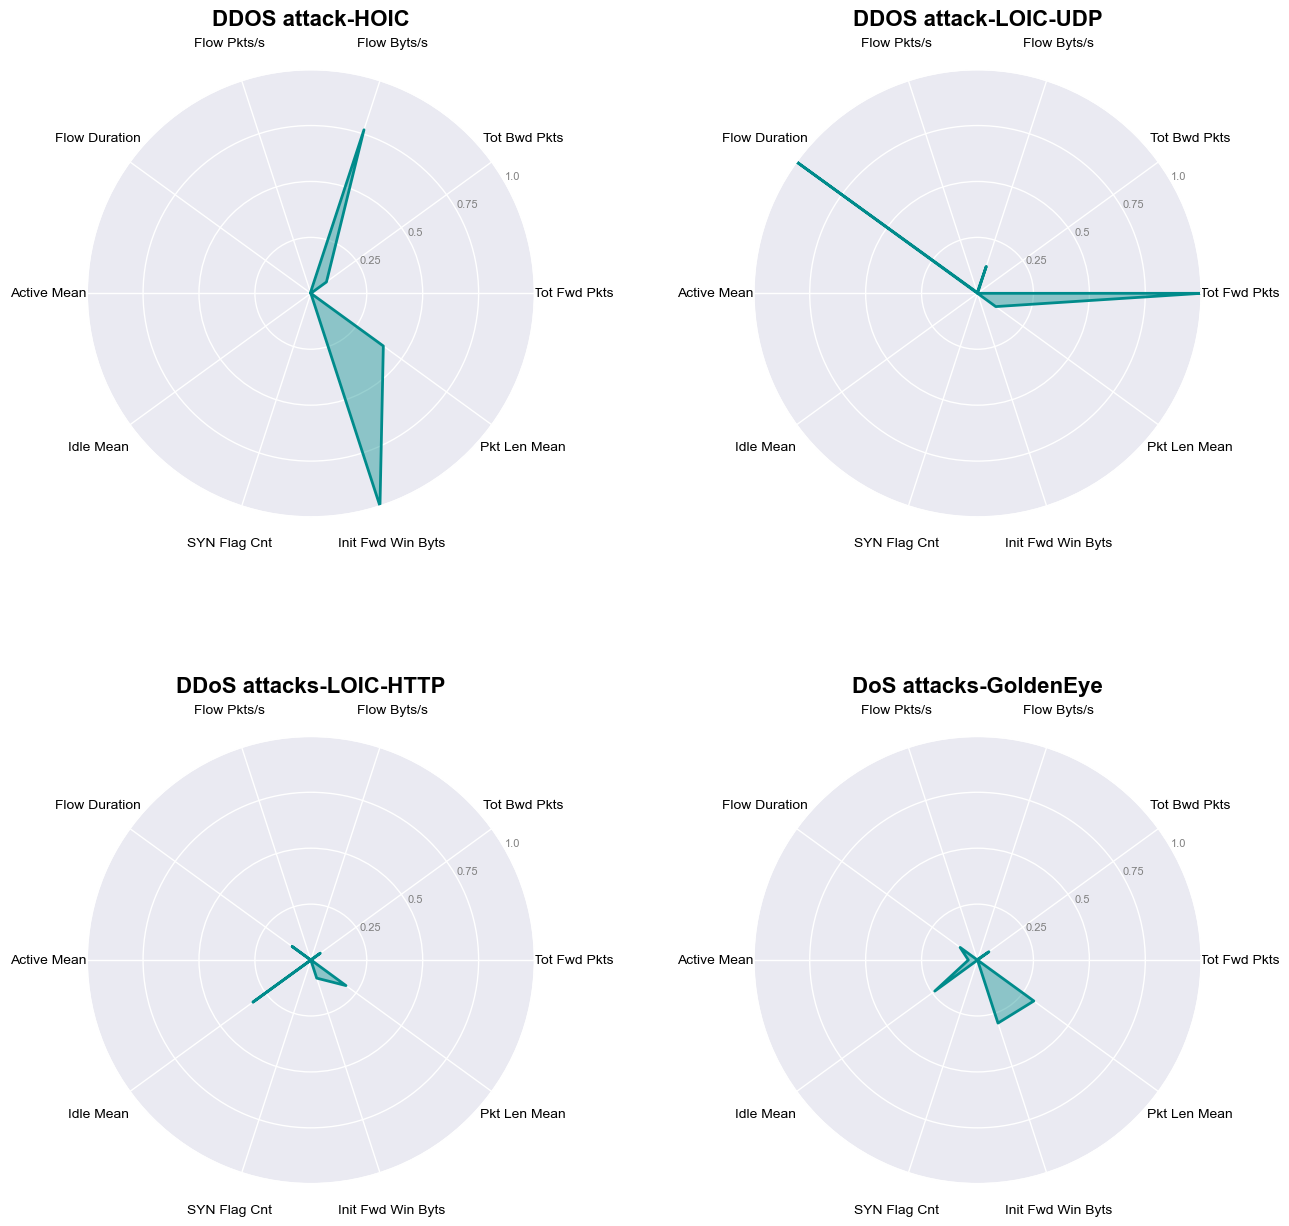

Successfully saved: Radar_10Features_Label_pt3.png


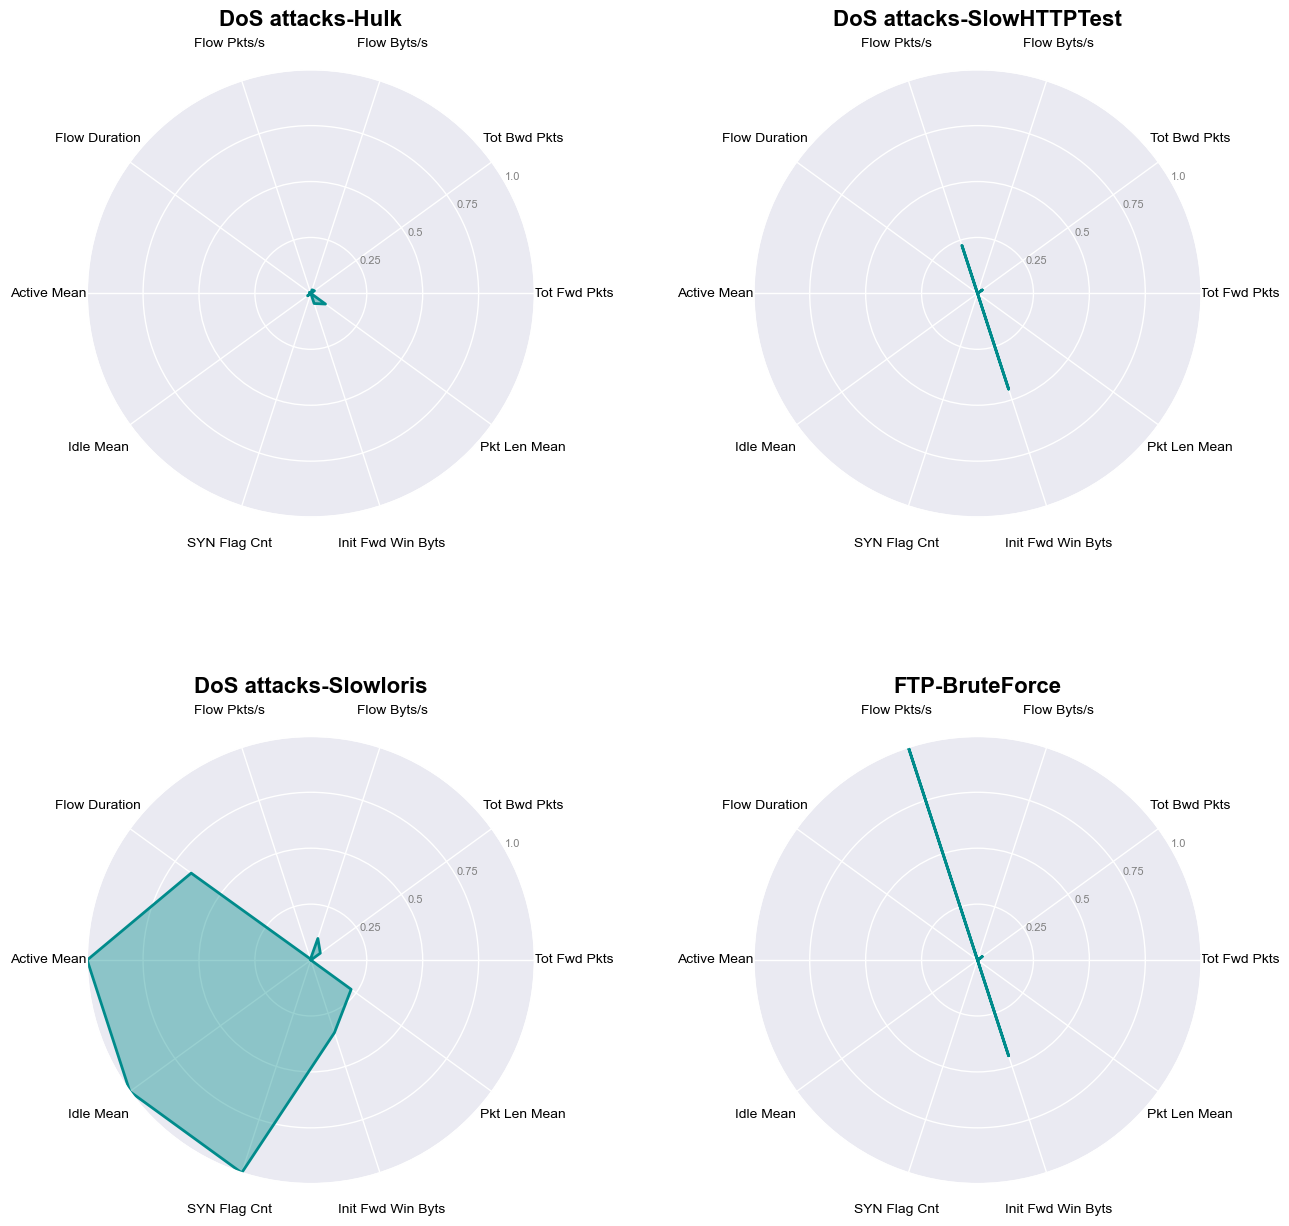

Successfully saved: Radar_10Features_Label_pt4.png


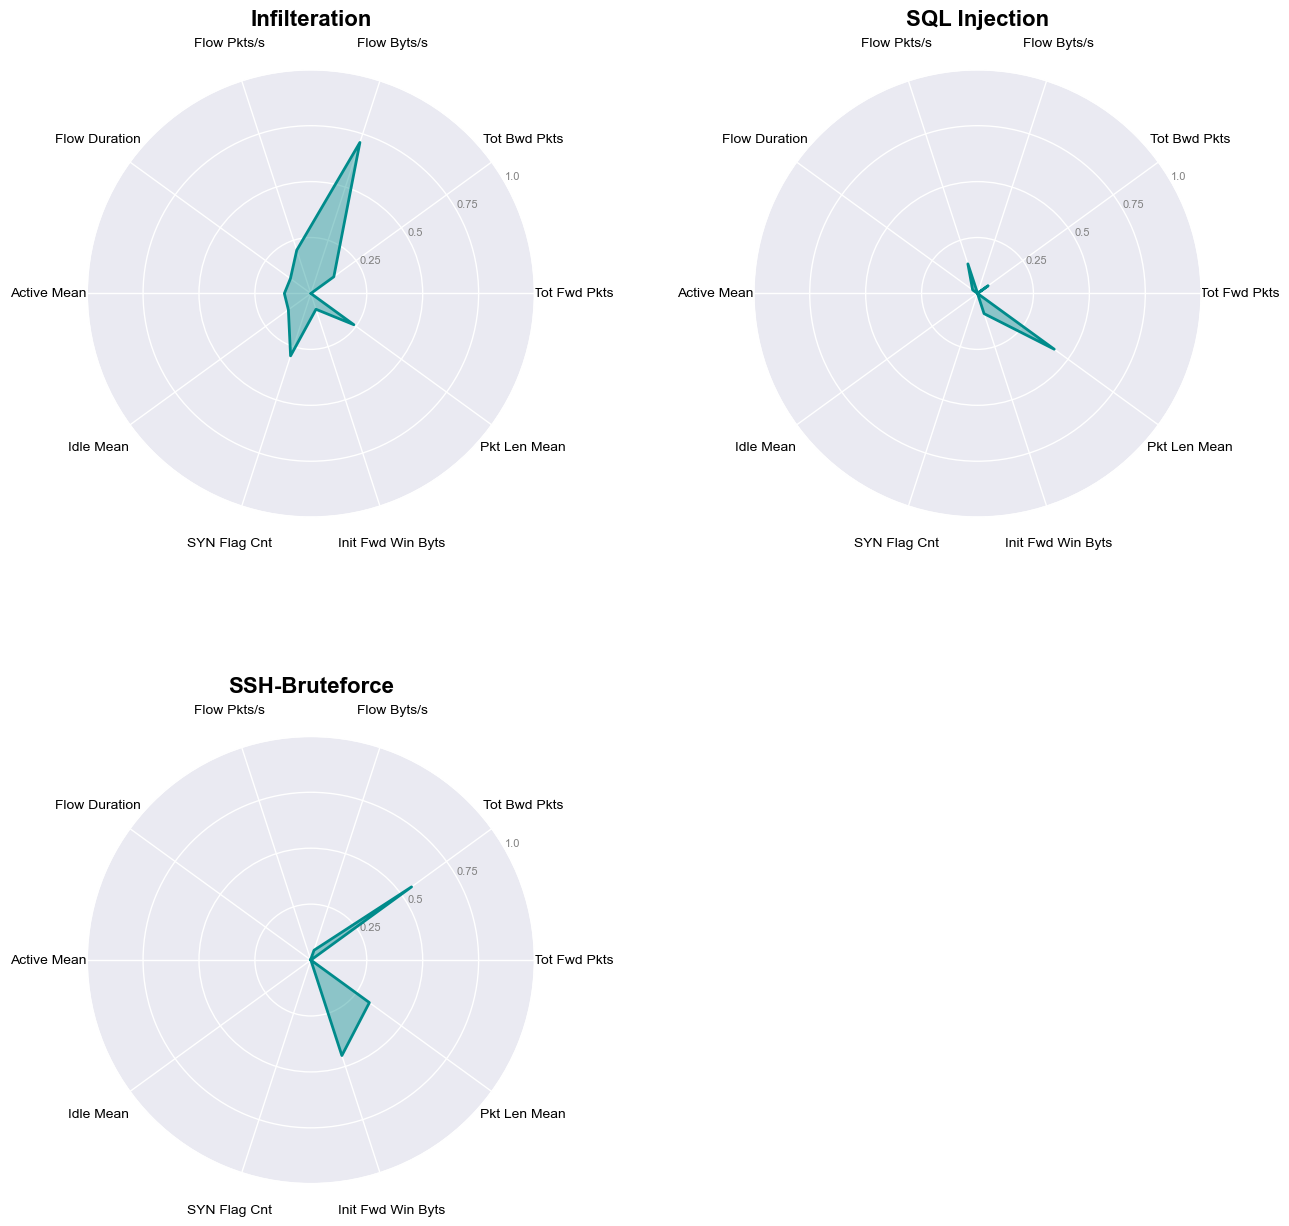

In [77]:
# Use the exact same 10 features
key_features = [
    'Tot Fwd Pkts', 'Tot Bwd Pkts', 
    'Flow Byts/s', 'Flow Pkts/s', 
    'Flow Duration', 'Active Mean', 'Idle Mean', 
    'SYN Flag Cnt', 'Init Fwd Win Byts', 
    'Pkt Len Mean'
]

# Defensive check: ensure features exist in our dataframe
features_to_use = [f for f in key_features if f in df.columns]

# Re-calculate the Min-Max normalized data
clean_df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=features_to_use)
mean_df = clean_df.groupby('Label')[features_to_use].mean()
normalized_df = (mean_df - mean_df.min()) / (mean_df.max() - mean_df.min())
normalized_df = normalized_df.fillna(0)

# Setup the Radar Chart mathematics
labels = list(normalized_df.columns)
num_vars = len(labels)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1] 

attack_types = normalized_df.index.tolist()

# Loop through the attacks in chunks of 4
chunk_size = 4

for i in range(0, len(attack_types), chunk_size):
    chunk = attack_types[i : i + chunk_size]
    
    # Calculate the current part number
    part_num = (i // chunk_size) + 1
    
    plt.figure(figsize=(14, 14))
    
    for j, attack in enumerate(chunk):
        ax = plt.subplot(2, 2, j + 1, polar=True)
        
        values = normalized_df.loc[attack].values.tolist()
        values += values[:1]
        
        # Set zorder=10 to bring text to the very front
        plt.xticks(angles[:-1], labels, color='black', size=10, zorder=10)
        
        # Push the labels slightly outward so they don't intersect the outer circle
        ax.tick_params(axis='x', pad=15)
        
        ax.set_rlabel_position(30)
        plt.yticks([0.25, 0.5, 0.75, 1.0], ["0.25", "0.5", "0.75", "1.0"], color="grey", size=8)
        plt.ylim(0, 1.0)
        
        # Push the polygons to the background using low zorder
        ax.plot(angles, values, linewidth=2, linestyle='solid', color='darkcyan', zorder=2)
        ax.fill(angles, values, 'darkcyan', alpha=0.4, zorder=1)
        
        # Title
        plt.title(attack, size=16, color='black', y=1.08, fontweight='bold')
        
    plt.tight_layout(pad=4.0) 
    
    # Save the figure
    filename = f'Radar_10Features_Label_pt{part_num}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Successfully saved: {filename}")
    
    plt.show()